In [158]:
import pandas as pd

In [159]:
end_year = 2024
region_analysis = "Europe_and_North_America_and_Japan"

global_universe = pd.read_csv(f"./data/Global_Universe/Global_Universe_{region_analysis}_{end_year}.csv")

# Accounting columns (t)
accounting_columns = list(global_universe.columns[14:24])


if "date" in global_universe.columns:
    global_universe["date"] = pd.to_datetime(global_universe["date"], errors="coerce")

required_cols = {"gvkey", "date"}
missing = required_cols - set(global_universe.columns)
if missing:
    raise ValueError(f"global_universe missing required columns: {sorted(missing)}")

# Ensure chronological order within each firm
global_universe = global_universe.sort_values(["gvkey", "date"], kind="mergesort").reset_index(drop=True)

k = 12
shifted = global_universe.groupby("gvkey", sort=False)[accounting_columns].shift(-k)
shifted.columns = [f"{c}_t_plus_{k}" for c in accounting_columns]
global_universe = pd.concat([global_universe, shifted], axis=1)

global_universe

,Unnamed: 0,gvkey_iid,year,month,date,gvkey,iid,mktcap,tri,year_x,...,cumulative_mktcap_t_plus_12,total_mktcap_t_plus_12,ebit_t_plus_12,roa0_t_plus_12,roa1_t_plus_12,roa2_t_plus_12,ros0_t_plus_12,ros1_t_plus_12,ros2_t_plus_12,sales_intensity_t_plus_12
0,31,001045_4,2016,7,2016-07-29,1045,4,1.881191e+10,36.195062,2016,...,6.472950e+12,2.345693e+13,6007.0,0.152767,0.117155,0.0482,0.194948,0.149502,0.064371,0.748778
1,32,001045_4,2016,8,2016-08-31,1045,4,1.923584e+10,37.121271,2016,...,5.854062e+12,2.342113e+13,6007.0,0.152767,0.117155,0.0482,0.194948,0.149502,0.064371,0.748778
2,33,001045_4,2016,9,2016-09-30,1045,4,1.940011e+10,37.438285,2016,...,6.113512e+12,2.406725e+13,6007.0,0.152767,0.117155,0.0482,0.194948,0.149502,0.064371,0.748778
3,34,001045_4,2016,10,2016-10-31,1045,4,2.103588e+10,41.518557,2016,...,6.035733e+12,2.454659e+13,6007.0,0.152767,0.117155,0.0482,0.194948,0.149502,0.064371,0.748778
4,35,001045_4,2016,11,2016-11-30,1045,4,2.406172e+10,47.611280,2016,...,6.470883e+12,2.519827e+13,6007.0,0.152767,0.117155,0.0482,0.194948,0.149502,0.064371,0.748778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121181,249527,361557_02W,2024,8,2024-08-30,361557,02W,4.903370e+09,28.048160,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121182,249528,361557_02W,2024,9,2024-09-30,361557,02W,4.015581e+09,22.969845,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121183,249529,361557_02W,2024,10,2024-10-31,361557,02W,4.023055e+09,23.012600,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121184,249530,361557_02W,2024,11,2024-11-29,361557,02W,3.672896e+09,21.009624,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [160]:
cols_12 = global_universe.columns[global_universe.columns.astype(str).str.contains("12")]
cols_12

Index(['cumulative_mktcap_t_plus_12', 'total_mktcap_t_plus_12',
       'ebit_t_plus_12', 'roa0_t_plus_12', 'roa1_t_plus_12', 'roa2_t_plus_12',
       'ros0_t_plus_12', 'ros1_t_plus_12', 'ros2_t_plus_12',
       'sales_intensity_t_plus_12'],
      dtype='object')

In [161]:
# Split global_universe into currency-based universes
usa_universe = global_universe[global_universe["curcdd"].eq("USD")].copy()
EU_universe = global_universe[global_universe["curcdd"].eq("EUR")].copy()
Japan_universe = global_universe[global_universe["curcdd"].eq("JPY")].copy()

In [162]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def corr_heatmap_xy(
    df: pd.DataFrame,
    y_vars: list[str],
    x_vars: list[str],
    *,
    method: str = "pearson",
    dropna: bool = True,
    annot: bool = True,
    fmt: str = ".2f",
    cmap: str = "vlag",
    center: float = 0.0,
    vmin: float | None = -1.0,
    vmax: float | None = 1.0,
    figsize: tuple[float, float] | None = None,
    title: str | None = None,
    save_path: str | None = None,
):
    """Plot correlation heatmap for selected row vars (y) vs column vars (x).

    Returns (corr_df, ax).
    """
    if dropna:
        cols = list(dict.fromkeys([*y_vars, *x_vars]))
        data = df.loc[:, cols].dropna(how="any")
    else:
        data = df

    corr_full = data.corr(method=method, numeric_only=True)
    corr_xy = corr_full.reindex(index=y_vars, columns=x_vars)

    if figsize is None:
        # Simple heuristic: scale with number of vars
        figsize = (max(6.0, 0.6 * len(x_vars)), max(4.5, 0.45 * len(y_vars)))

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr_xy,
        ax=ax,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        square=False,
        cbar_kws={"label": f"{method} correlation"},
    )
    ax.set_xlabel("x variables")
    ax.set_ylabel("y variables")
    if title:
        ax.set_title(title)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    return corr_xy, ax


In [163]:

signal_columns = global_universe.columns[29:33]
accounting_columns = global_universe.columns[14:24]


# Spearman Deals with outliers

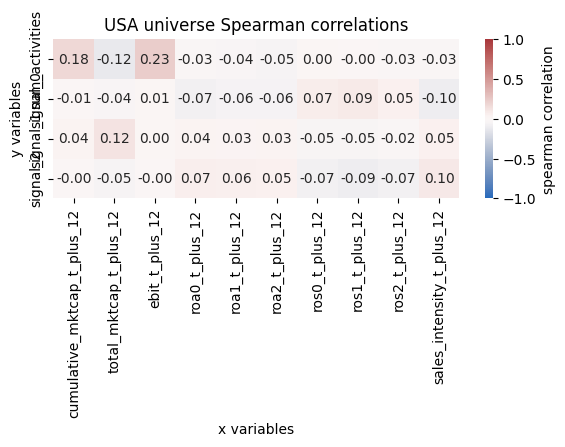

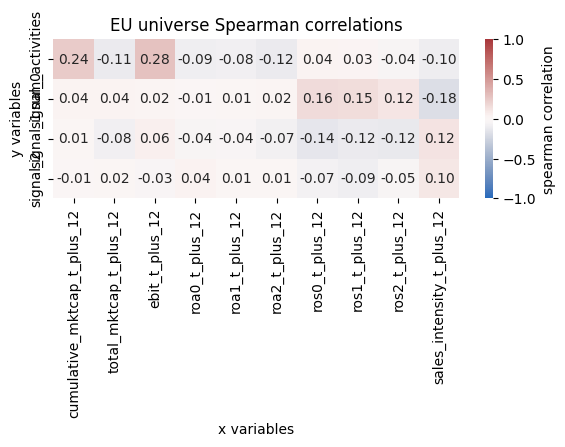

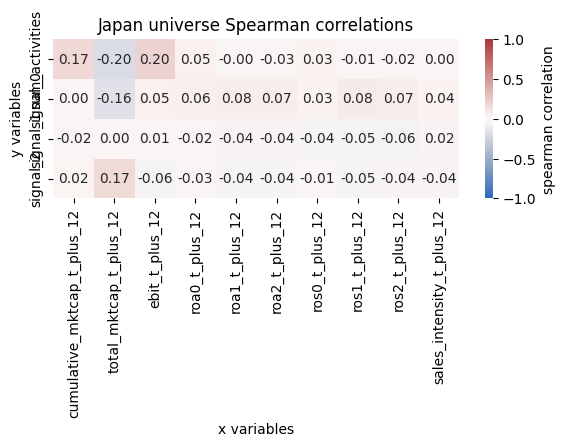

In [164]:
# Spearman version (rank correlation) for all regions
universes = {
    "USA": usa_universe,
    "EU": EU_universe,
    "Japan": Japan_universe,
}

corr_blocks_spearman = {}
for region, universe_df in universes.items():
    corr_xy, ax = corr_heatmap_xy(
        universe_df,
        y_vars=signal_columns,
        x_vars=cols_12,
        method="spearman",
        title=f"{region} universe Spearman correlations",
    )
    corr_blocks_spearman[region] = corr_xy

